In [1]:
import dotenv
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itables import init_notebook_mode

init_notebook_mode(all_interactive=True)

In [2]:
try:
    train = pd.read_csv("data/train.csv")
    test = pd.read_csv("data/test.csv")
except FileNotFoundError:
    dotenv.load_dotenv(dotenv.find_dotenv())
    kagglehub.login()
    kagglehub.competition_download("playground-series-s6e3", output_dir = "./data")

0. Prepare data

In [3]:
def _preprocess(df: pd.DataFrame) -> pd.DataFrame:
    # df["SeniorCitizen"] = df["SeniorCitizen"].astype("str")
    df["gender"] = pd.Categorical(df["gender"], categories = ["Female", "Male"])
    df["Contract"] = pd.Categorical(df["Contract"],
                                  categories = ["Month-to-month", "One year", "Two year"],
                                  ordered = True)
    df["PaymentMethod"] = pd.Categorical(df["PaymentMethod"],
                                        categories = ["Electronic check", "Mailed check",
                                                      "Bank transfer (automatic)",
                                                      "Credit card (automatic)"])
    df["InternetService"] = pd.Categorical(df["InternetService"],
                                           categories = ["No", "DSL", "Fiber optic"],
                                           ordered = True)
    binary_columns = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]
    for col in binary_columns:
        if col in df.columns:
            df[col] = df[col].replace({"Yes": 1, "No": 0}).astype("int")
    df["MultipleLines"] = pd.Categorical(df["MultipleLines"],
                                        categories = ["No phone service", "No", "Yes"],
                                        ordered = True)
    for col in ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV",
                "StreamingMovies"]:
        df[col] = pd.Categorical(df[col],
                                categories = ["No internet service", "No", "Yes"],
                                ordered = True)
    return df

train = _preprocess(train)
test = _preprocess(test)

1. Univariant analysis

In [5]:
categorical_cols = [
    x for x in train.columns if (pd.api.types.is_string_dtype(train[x]) and x not in ["id"])
]
additional_categorical_cols = ["SeniorCitizen", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]
categorical_cols += additional_categorical_cols
numerical_cols = [x for x in train.columns if pd.api.types.is_numeric_dtype(train[x]) and x not in ["id", "Churn"] + additional_categorical_cols]

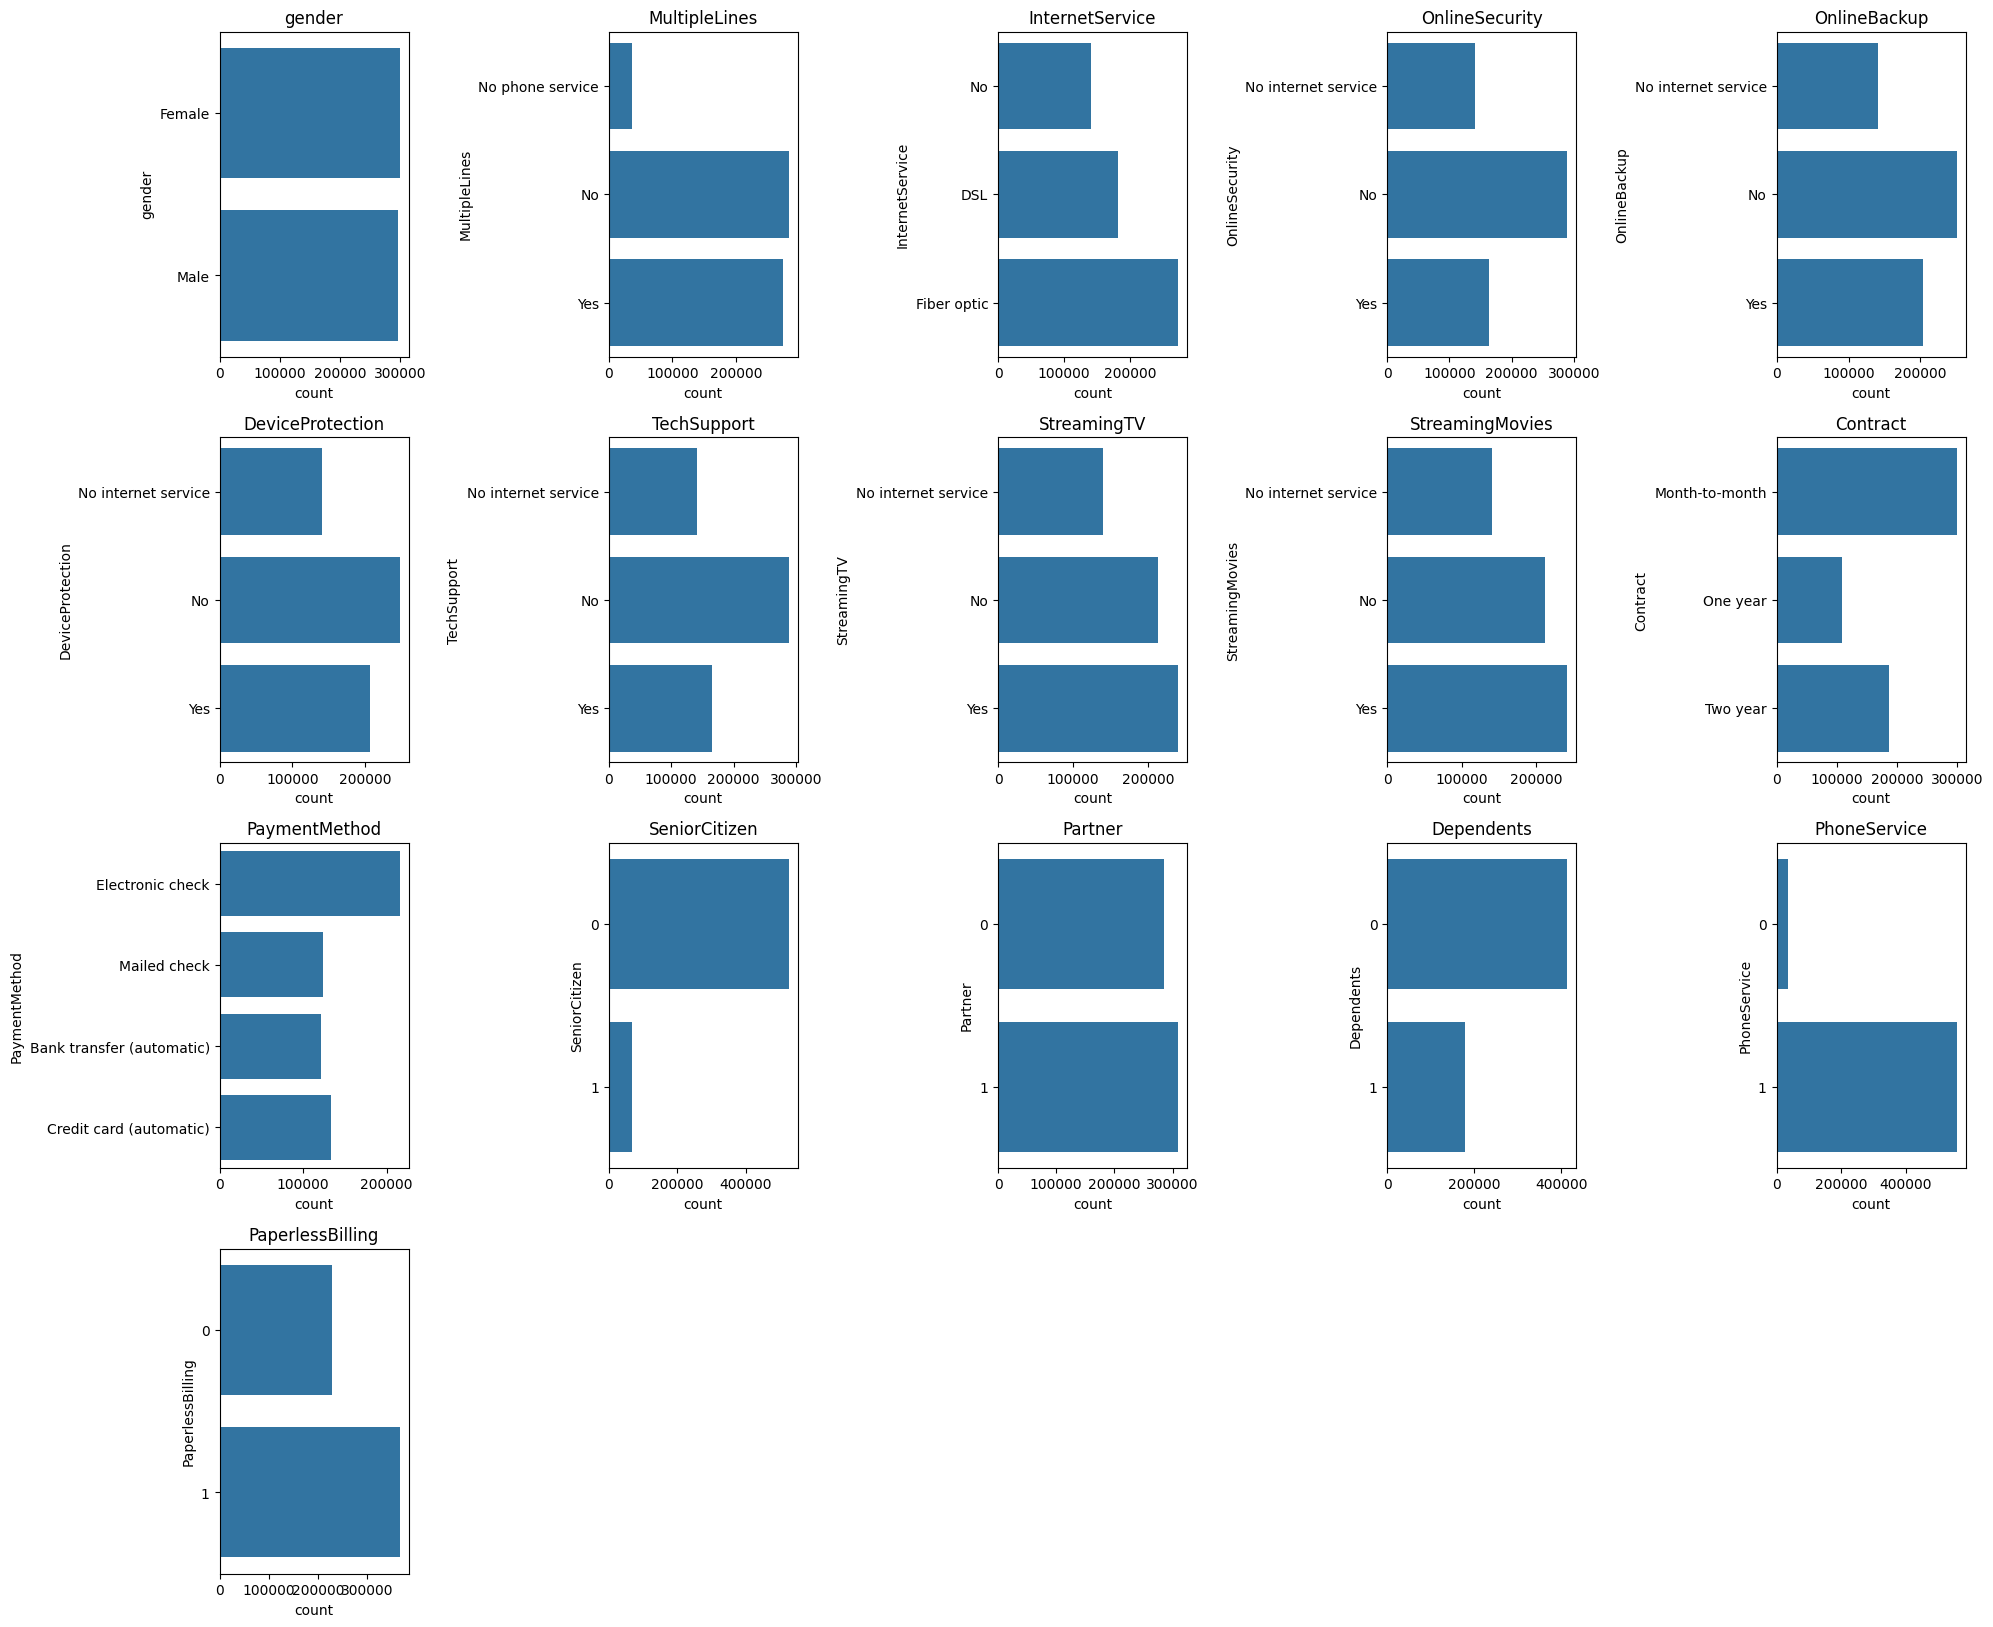

In [6]:
# barplots of each categorical variable

plt.figure(figsize=(20, 20))
for col in categorical_cols:
    plt.subplot(5, 5, categorical_cols.index(col) + 1)
    sns.countplot(y=col, data=train)
    plt.title(col)
plt.tight_layout()
plt.show()

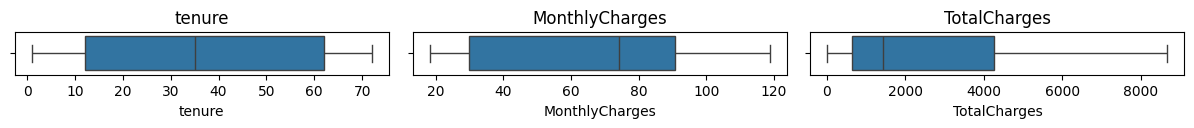

In [7]:
# boxplots of each numerical variable
plt.figure(figsize=(20, 5))
for col in numerical_cols:
    plt.subplot(5, 5, numerical_cols.index(col) + 1)
    sns.boxplot(x=col, data=train)
    plt.title(col)
plt.tight_layout()
plt.show()

In [8]:
train["Churn"].value_counts(normalize=True)

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


2. Bivariant analysis

In [9]:
from forecasting_toolkit import compute_chi2

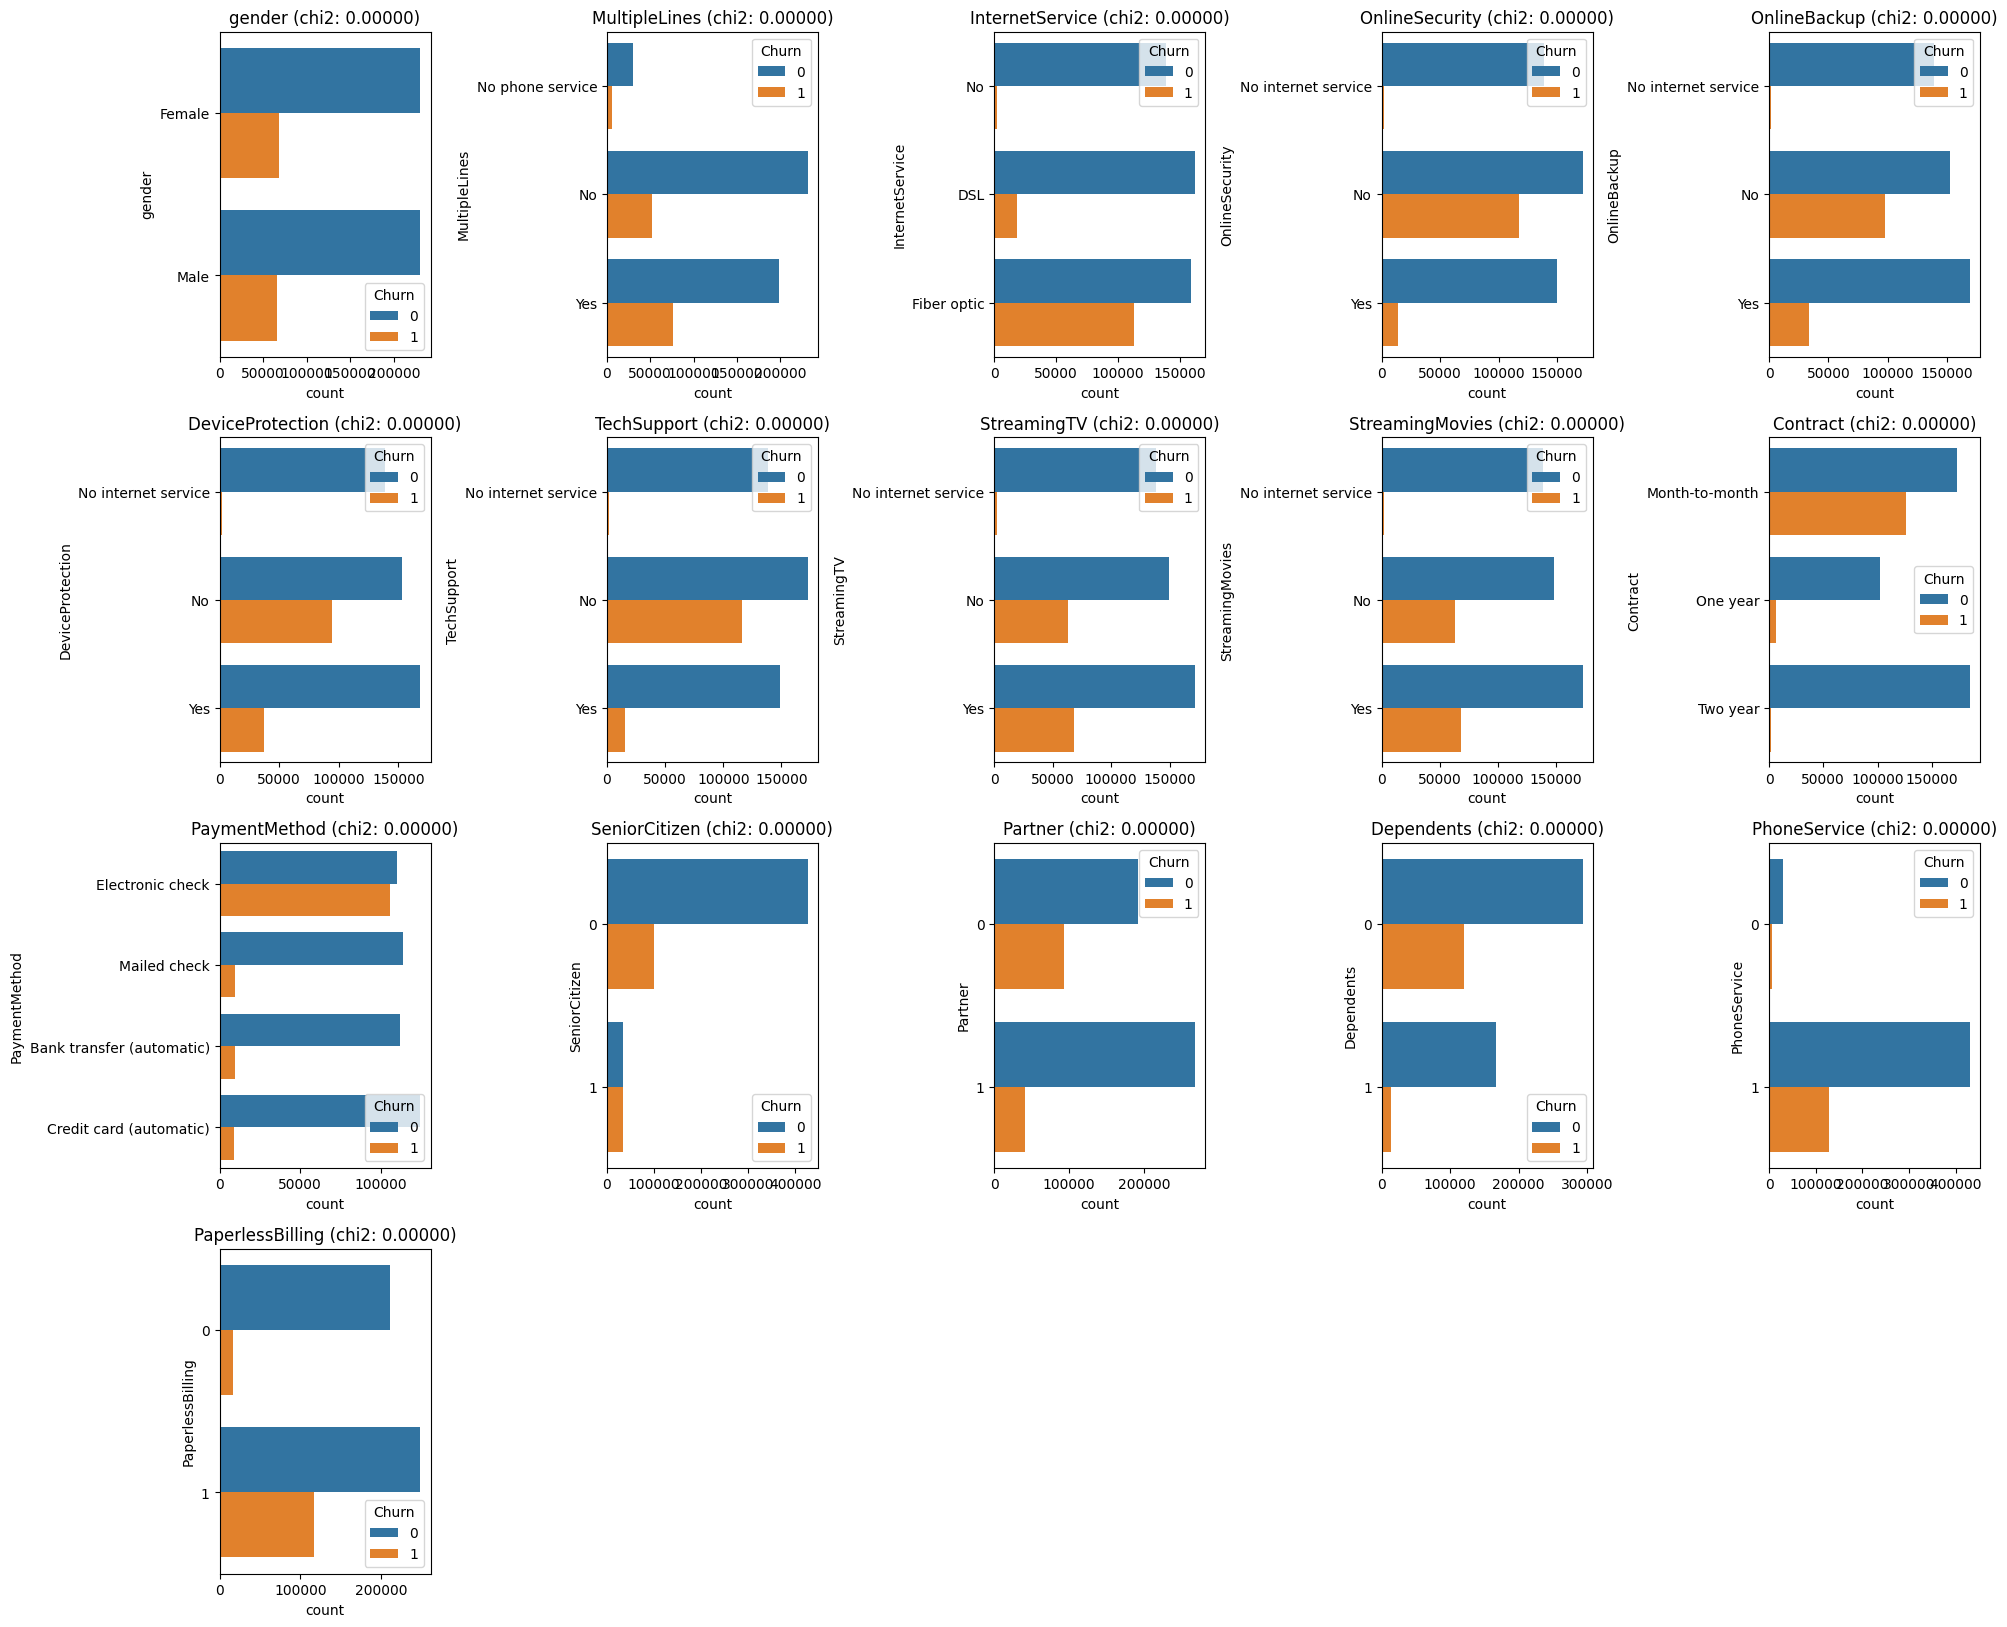

In [10]:
chi2_values = compute_chi2(train.rename(columns={"Churn": "target"}), categorical_v=categorical_cols)
chi2_values = chi2_values[chi2_values["variable"] != "target"]
# plot all categorical variables in vertical barplots split by Churn, with the chi2 value in the title
plt.figure(figsize=(20, 20))
for col in categorical_cols:
    plt.subplot(5, 5, categorical_cols.index(col) + 1)
    sns.countplot(y=col, hue = "Churn", data=train)
    plt.title(f"{col} (chi2: {chi2_values[chi2_values["variable"] == col]["pvalue"].values[0]:.5f})")
plt.tight_layout()
plt.show()

<Axes: >

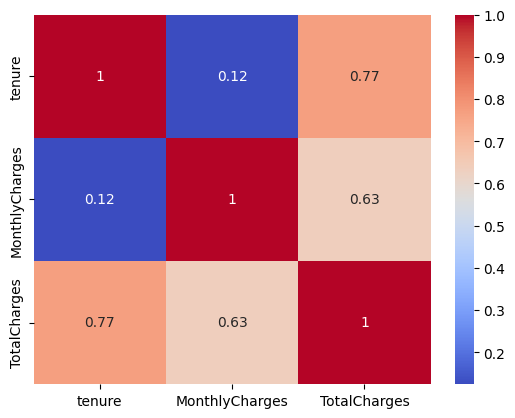

In [11]:
# train[numerical_cols].corr().plot(kind = "heatmap", annot=True, cmap="coolwarm")
sns.heatmap(train[numerical_cols].corr(), annot=True, cmap="coolwarm")